<a href="https://colab.research.google.com/github/marianoInsa/ONE-TelecomX-2/blob/main/notebooks/03_modelado_predictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Telecom X - Parte 2.3: Modelado Predictivo

Con las features seleccionadas y los datos preparados en los notebooks anteriores, entramos en la fase central del proyecto: **construir modelos de machine learning que predigan qué clientes cancelarán su servicio**.

En la Parte 2.1 transformamos el dataset crudo al formato que los algoritmos requieren (encoding, escalado, balanceo). En la Parte 2.2 identificamos las variables con mayor poder predictivo mediante correlación de Pearson, Información Mutua y análisis de multicolinealidad (VIF). Ahora, con el terreno preparado, pasamos a la acción.

Este notebook se estructura en **tres pasos**:

| Paso | Objetivo |
|---|---|
| **1. Separación de Datos** | Dividir el dataset en entrenamiento y prueba, aplicar balanceo, y generar los artefactos que alimentarán los modelos |
| **2. Creación de Modelos** | Entrenar al menos dos modelos de clasificación con estrategias de normalización diferenciadas |
| **3. Evaluación de los Modelos** | Comparar rendimiento con métricas de clasificación y analizar posibles problemas de overfitting/underfitting |

---
## ⚙️ Configuración del Entorno

In [8]:
# Configuración del path para importar módulos desde src/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Importación de módulos del proyecto
import joblib
import pandas as pd

from src.config import (
    DATA_PROCESSED_DIR,
    MODELS_DIR,
    RANDOM_STATE,
    TEST_SIZE,
    setup_plot_style,
)
from src.preprocessing import (
    load_selected_features,
    scale_features,
    split_and_balance,
)
from src.visualization import plot_smote_comparison

# Aplicar estilo visual
setup_plot_style()
print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


---
## 📥 Carga de Artefactos Previos

Cargamos los dos artefactos generados en los notebooks anteriores:

1. **`telecom_encoded.csv`** (Notebook 01): El dataset completo con todas las variables codificadas numéricamente, listo para ML.
2. **`selected_features.json`** (Notebook 02): La lista de 20 features que superaron el umbral de relevancia ($|r| \geq 0.15$), junto con el registro de las 10 features descartadas.

Este encadenamiento entre notebooks garantiza la **reproducibilidad** del pipeline: cada etapa consume los artefactos de la anterior sin repetir procesamiento.

In [9]:
# Cargar el dataset procesado (Notebook 01)
df_encoded = pd.read_csv(DATA_PROCESSED_DIR / 'telecom_encoded.csv')

print(f'📂 Dataset cargado: {df_encoded.shape[0]} filas × {df_encoded.shape[1]} columnas')
print(f'✅ Todas las columnas son numéricas: {all(df_encoded.dtypes != object)}')

# Cargar las features seleccionadas (Notebook 02)
selected_features = load_selected_features()

df_encoded.head(3)

📂 Dataset cargado: 7043 filas × 31 columnas
✅ Todas las columnas son numéricas: True
📂 Features cargadas desde: selected_features.json
   Método de selección : pearson_abs
   Umbral aplicado     : |r| >= 0.15
   Features retenidas  : 20 columnas


,Churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,customer_gender_Male,...,internet_techsupport_Yes,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,0,...,1,0,1,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0,59.9,542.40,1,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,1,...,0,0,0,0,0,0,0,0,1,0


---
# Paso 1: Separación de Datos

Antes de entrenar cualquier modelo, es imprescindible **dividir el dataset en dos conjuntos independientes**: uno para que el modelo aprenda los patrones (entrenamiento) y otro para evaluar su capacidad de generalización (prueba).

¿Por qué es tan importante? Si evaluamos un modelo con los mismos datos que usó para aprender, obtenemos métricas artificialmente altas que no reflejan su rendimiento real. Es como estudiar con las respuestas del examen: la nota será perfecta, pero no demuestra conocimiento real. Este problema se conoce como **data leakage** y es uno de los errores más comunes (y costosos) en machine learning.

### Decisiones de diseño

| Decisión | Elección | Justificación |
|---|---|---|
| **Proporción** | 80% train / 20% test | Con ~7.043 registros, el 20% (~1.409) provee suficiente masa estadística para una evaluación robusta. Una partición 70/30 sería igualmente válida, pero reduciría los datos disponibles para entrenamiento sin beneficio significativo en la evaluación. |
| **Estratificación** | `stratify=y` | Garantiza que ambos conjuntos mantengan la misma proporción de churn (~26.5%) que el dataset original. Sin estratificar, el azar podría generar un test set con una distribución atípica, invalidando las métricas. |
| **Balanceo (SMOTE)** | Solo en train | Los ejemplos sintéticos se generan exclusivamente sobre el conjunto de entrenamiento. El test set preserva la distribución real del mundo para que la evaluación sea fiel. |
| **Escalado pre-SMOTE** | `StandardScaler` antes de SMOTE | SMOTE utiliza distancia euclidiana (k-NN) para interpolar vecinos. Sin escalar, features con rangos amplios (como `account_charges_total`) dominarían el cálculo, sesgando los ejemplos sintéticos. **Este escalado es un requisito técnico de SMOTE**, no una decisión de normalización para los modelos — esa decisión se tomará en el Paso 2. |
| **Semilla** | `RANDOM_STATE = 42` | Semilla fija para reproducibilidad total. Cualquier re-ejecución produce exactamente los mismos conjuntos. |

---
## 1.1 División Estratificada y Balanceo (Split → Scale → SMOTE)

El pipeline completo se ejecuta en un solo paso a través de la función `split_and_balance()`, que encapsula la secuencia correcta:

```
Dataset completo
      │
      ▼
  train_test_split(stratify=y)  ─── 80% Train ───┐
      │                                          │
      │                                    StandardScaler
      │                                    (fit en train)
      │                                          │
      │                                        SMOTE
      │                                    (solo en train)
      │                                          │
      ▼                                          ▼
   20% Test                               Train balanceado
  (escalado)                                 (escalado)
Distribución real                            50% / 50%
```

El scaler se ajusta (fit) **exclusivamente** en el train set y se aplica (transform) a ambos conjuntos, previniendo cualquier fuga de información del test al proceso de escalado.

In [10]:
# Separación de features y variable objetivo
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Pipeline integrado: split estratificado → escalado → SMOTE
split = split_and_balance(X, y, apply_smote=True, scale_before_smote=True)

# Desempaquetar artefactos
X_train_bal = split.X_train_bal     # Escalado + balanceado (para entrenamiento)
y_train_bal = split.y_train_bal
X_test      = split.X_test          # Escalado (test real, sin modificar distribución)
y_test      = split.y_test
X_train     = split.X_train         # Train original sin escalar ni balancear (referencia)
y_train     = split.y_train
scaler      = split.scaler          # StandardScaler ajustado en train

=== División Train / Test ===
  Train : 5634 registros  (80.0%)
  Test  : 1409  registros  (20.0%)
  Features: 30 columnas

  Distribución en Train | Churn: 26.54%
  Distribución en Test  | Churn: 26.54%
=== Verificación del escalado (Train) ===
  Media promedio de todas las features : 0.000000  (esperado ≈ 0)
  Std  promedio de todas las features  : 1.000000  (esperado ≈ 1)

  Shape X_train_scaled : (5634, 30)
  Shape X_test_scaled  : (1409, 30)

✅ Estandarización completada.

✅ Escalado aplicado ANTES de SMOTE (distancia euclidiana corregida).

=== Distribución después de SMOTE (Train) ===
  Clase 0 | No canceló :  4139 registros (50.0%)
  Clase 1 | Canceló    :  4139 registros (50.0%)

  Ejemplos sintéticos generados: 2644 nuevos registros de churn

✅ Test set permanece intacto: 1409 registros (sin modificar)


---
## 1.2 Verificación de la Estratificación

Confirmamos que `stratify=y` cumplió su función: la proporción de churn debe ser prácticamente idéntica en el dataset original, el train set (pre-SMOTE) y el test set.

In [11]:
print('=== Verificación de Estratificación ===')
print(f'{"Conjunto":<25} {"Registros":>10} {"Churn %":>10}')
print('-' * 47)
print(f'{"Dataset original":<25} {len(y):>10,} {y.mean():>10.2%}')
print(f'{"Train (pre-SMOTE)":<25} {len(y_train):>10,} {y_train.mean():>10.2%}')
print(f'{"Test":<25} {len(y_test):>10,} {y_test.mean():>10.2%}')
print('-' * 47)

diff = abs(y_train.mean() - y_test.mean())
print(f'\n  Diferencia train-test: {diff:.4f} ({"✅ < 1%" if diff < 0.01 else "⚠️ > 1%"})')
print(f'  Proporción de churn preservada en ambos conjuntos.')

=== Verificación de Estratificación ===
Conjunto                   Registros    Churn %
-----------------------------------------------
Dataset original               7,043     26.54%
Train (pre-SMOTE)              5,634     26.54%
Test                           1,409     26.54%
-----------------------------------------------

  Diferencia train-test: 0.0001 (✅ < 1%)
  Proporción de churn preservada en ambos conjuntos.


---
## 1.3 Efecto del Balanceo (SMOTE)

En el notebook 01 detectamos un desbalance de **~2.77:1** (No Churn / Churn). Sin corregirlo, los modelos tenderían a predecir siempre la clase mayoritaria ("el cliente se queda"), logrando una accuracy engañosa del ~73% pero fallando en detectar los casos de churn — que son precisamente los que Telecom X necesita identificar.

SMOTE (Synthetic Minority Oversampling Technique) generó ejemplos sintéticos de la clase minoritaria interpolando entre vecinos cercanos, **solo dentro del train set**. El test set mantiene su distribución real (~26.5% churn) para que la evaluación sea representativa del mundo real.

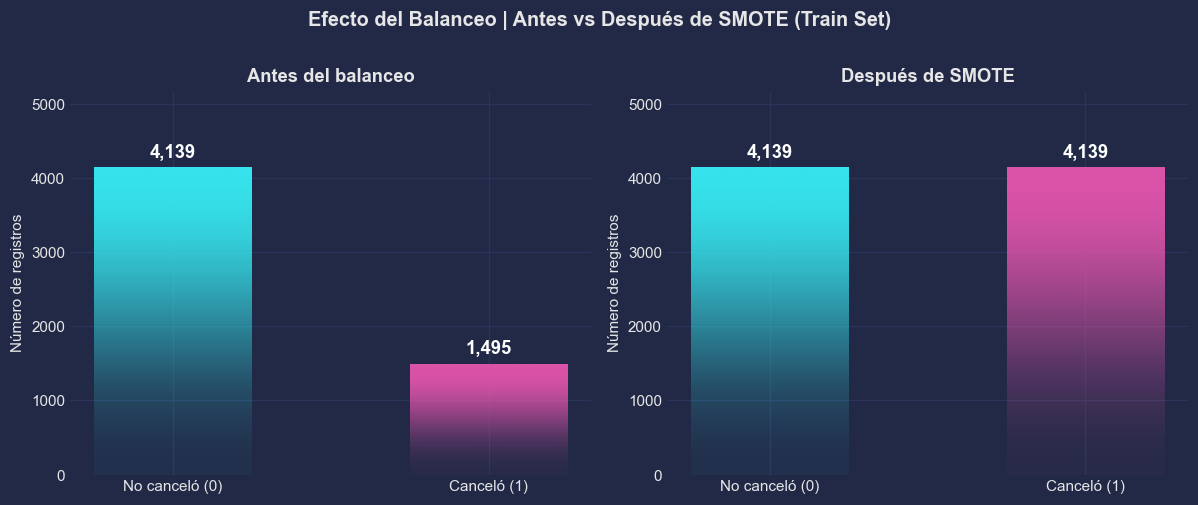

In [12]:
plot_smote_comparison(y_train, y_train_bal)

---
## 1.4 Artefactos Disponibles para el Modelado

El pipeline de separación generó todos los conjuntos necesarios para entrenar y evaluar modelos en los pasos siguientes. A continuación, un inventario completo:

| Variable | Descripción | Dimensiones | Uso previsto |
|---|---|---|---|
| `X_train_bal`, `y_train_bal` | Train escalado + balanceado (todas las features) | — | Entrenamiento de todos los modelos |
| `X_test`, `y_test` | Test escalado (distribución real sin modificar) | — | Evaluación de todos los modelos |
| `X_train`, `y_train` | Train original sin escalar ni balancear | — | Referencia y comparación |
| `selected_features` | Lista de 20 features | 20 cols | Filtrado en Paso 2 para modelos que lo requieran |
| `scaler` | `StandardScaler` ajustado en train | — | Transformar nuevos datos en producción |

> **Nota sobre la estrategia dual de features:** El notebook 02 estableció que los modelos basados en árboles (Random Forest, etc.) pueden usar todas las features, mientras que los modelos sensibles a escala (Regresión Logística, etc.) se benefician de usar solo las features seleccionadas. El filtrado concreto (`X_train_bal[selected_features]`) se aplicará en el Paso 2 según el modelo que se entrene.

In [13]:
print('=== Dimensiones de los artefactos ===')
print(f'{"Artefacto":<25} {"Shape":>20}')
print('-' * 47)
print(f'{"X_train_bal":<25} {str(X_train_bal.shape):>20}')
print(f'{"y_train_bal":<25} {str(y_train_bal.shape):>20}')
print(f'{"X_test":<25} {str(X_test.shape):>20}')
print(f'{"y_test":<25} {str(y_test.shape):>20}')
print(f'{"X_train (referencia)":<25} {str(X_train.shape):>20}')
print(f'{"y_train (referencia)":<25} {str(y_train.shape):>20}')
print('-' * 47)
print(f'{"selected_features":<25} {len(selected_features):>17} cols')
print(f'{"scaler":<25} {type(scaler).__name__:>20}')

=== Dimensiones de los artefactos ===
Artefacto                                Shape
-----------------------------------------------
X_train_bal                         (8278, 30)
y_train_bal                            (8278,)
X_test                              (1409, 30)
y_test                                 (1409,)
X_train (referencia)                (5634, 30)
y_train (referencia)                   (5634,)
-----------------------------------------------
selected_features                        20 cols
scaler                          StandardScaler


---
## 💾 Persistencia de Artefactos

Guardamos los conjuntos de datos y el scaler en disco para garantizar la **reproducibilidad** del pipeline. Esto permite:
- Re-ejecutar los pasos de modelado y evaluación sin necesidad de repetir la separación.
- Consumir los mismos datos desde otros notebooks o scripts.
- Reutilizar el scaler para transformar nuevos datos en producción.

Los CSVs se guardan en `data/processed/` y el scaler serializado en `models/`, siguiendo las convenciones del proyecto.

In [14]:
# Persistir conjuntos de datos
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train_bal.to_csv(DATA_PROCESSED_DIR / 'X_train_bal.csv', index=False)
y_train_bal.to_csv(DATA_PROCESSED_DIR / 'y_train_bal.csv', index=False)
X_test.to_csv(DATA_PROCESSED_DIR / 'X_test.csv', index=False)
y_test.to_csv(DATA_PROCESSED_DIR / 'y_test.csv', index=False)

# Persistir el scaler para producción
scaler_path = MODELS_DIR / 'scaler_modelado.pkl'
joblib.dump(scaler, scaler_path)

print('✅ Artefactos exportados:')
print(f'   📁 data/processed/X_train_bal.csv  ({X_train_bal.shape})')
print(f'   📁 data/processed/y_train_bal.csv  ({y_train_bal.shape})')
print(f'   📁 data/processed/X_test.csv       ({X_test.shape})')
print(f'   📁 data/processed/y_test.csv       ({y_test.shape})')
print(f'   📁 models/scaler_modelado.pkl      ({type(scaler).__name__})')

✅ Artefactos exportados:
   📁 data/processed/X_train_bal.csv  ((8278, 30))
   📁 data/processed/y_train_bal.csv  ((8278,))
   📁 data/processed/X_test.csv       ((1409, 30))
   📁 data/processed/y_test.csv       ((1409,))
   📁 models/scaler_modelado.pkl      (StandardScaler)


---
## ✅ Resumen del Paso 1: Separación de Datos

El dataset fue dividido y transformado siguiendo un pipeline riguroso que previene data leakage en cada etapa:

| Paso | Acción | Justificación |
|---|---|---|
| **Split 80/20** | `train_test_split` con `stratify=y` | Proporción de churn preservada (~26.5%) en ambos conjuntos |
| **Escalado** | `StandardScaler` (fit solo en train) | Requisito técnico de SMOTE: distancia euclidiana equitativa |
| **SMOTE** | Balanceo 50/50 solo en train | Corrige desbalance 2.77:1 sin contaminar el test set |
| **Persistencia** | CSVs + scaler serializado | Reproducibilidad total del pipeline |

### Artefactos generados

| Archivo | Ubicación | Contenido |
|---|---|---|
| `X_train_bal.csv` | `data/processed/` | Features de entrenamiento (escaladas + balanceadas) |
| `y_train_bal.csv` | `data/processed/` | Target de entrenamiento (balanceado 50/50) |
| `X_test.csv` | `data/processed/` | Features de prueba (escaladas, distribución real) |
| `y_test.csv` | `data/processed/` | Target de prueba (distribución real ~26.5% churn) |
| `scaler_modelado.pkl` | `models/` | Scaler para transformar nuevos datos en producción |

Con los datos correctamente separados y balanceados, estamos listos para el siguiente paso: entrenar modelos de clasificación que aprendan a distinguir entre clientes que permanecen y los que cancelan.

---
# Paso 2: Creación de Modelos

En este paso entrenaremos al menos dos modelos de clasificación con estrategias diferenciadas: un modelo sensible a la escala de los datos (como Regresión Logística o KNN, donde la normalización es clave para que coeficientes y distancias se calculen correctamente) y un modelo basado en árboles (como Random Forest o Árbol de Decisión, que no depende de la escala). Esta diversidad permite comparar enfoques complementarios y evaluar qué familia de algoritmos captura mejor los patrones de churn.

*Próximamente...*

---
# Paso 3: Evaluación de los Modelos

Cada modelo será evaluado con las métricas de clasificación estándar — Accuracy, Precision, Recall, F1-score y Matriz de Confusión — seguido de un análisis crítico comparativo. Se investigará si algún modelo presenta overfitting (memoriza el train set sin generalizar) o underfitting (no captura los patrones subyacentes), y se propondrán ajustes en consecuencia.

*Próximamente...*